| **Task**                      | **Sub-task**                                         | **Comments**                                                                 |
|------------------------------|------------------------------------------------------|------------------------------------------------------------------------------|
| **Data Preprocessing**       | Scaling and Resizing                                | Done - Resized to (224x224) and normalized to [0,1]                       |
|                              | Image Augmentation                                  | Done - Random crop, horizontal flip, color jitter                         |
|                              | Train and test data handled correctly               | Done - Properly split into train, val, and test sets                      |
|                              | Gaussian Blur, Histogram Equalization, Thresholding | Not used for this model                                                                 |
| **Model Trained**            | Training Time?                                      | Done - EfficientNet trained and fine-tuned over multiple epochs           |
| **Evaluation**               | AUC and Confusion Matrix Computed                   | Done - Confusion matrix and classification report plotted                 |
|                              | Overfitting/Underfitting checked and handled        | Done - Early stopping and fine-tuning used to prevent overfitting         |
| **Data Centric AI Dev.**     | Interpretability Implemented                        | Done - LIME applied to visualize class predictions                        |
|                              | Major Findings                                      | Model most confident on **food**, **drink**, **menu**; **inside** needs attention |

| **Tuning Round**             | **Issue Faced**                                      | **Fix / Result**                                                             |
|-----------------------------|------------------------------------------------------|------------------------------------------------------------------------------|
| **1st Round of Tuning**     | Needed better generalization                         | Replaced classifier head → Validation accuracy improved to **93.1%**        |
| **2nd Round of Tuning**     | Slight overfitting still present                     | Unfroze last 5 layers + low LR fine-tuning → Test accuracy **95.4%**        |


***Reused preprocessing code from CV Case Study 1 by @pavan kumar pilli*** 
- resize and normalize 
- augmentation

## Run from "Loaded the datasets" block with cleaned datasets given

In [ ]:
pip install opencv-python-headless

In [ ]:
pip install tqdm

In [ ]:
pip install scikit-learn

In [ ]:
pip install matplotlib

In [5]:
import json
import pandas as pd
from collections import Counter
import os
import glob
import cv2
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torch.optim as optim
import time
from tqdm import tqdm
import shutil
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, recall_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from PIL import Image
import matplotlib.pyplot as plt
from shutil import copy2
from torchvision import transforms, datasets
import random
from PIL import Image, ImageEnhance
from torch.utils.data import Dataset, DataLoader

In [6]:
warnings.filterwarnings('ignore')

### Loading the metadata

In [7]:

def load_photo_metadata(json_path):
    data = []
    with open(json_path, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)

photo_df = load_photo_metadata('photos.json')

In [8]:
photo_df.sample(2)

,photo_id,business_id,caption,label
178527,WL9T2HoX79_-EZl4GG6Nsw,5xokROlB8Zo5T-_qbHzsrQ,,inside
63253,lHK4c56SFDXIT6vLhbzUsQ,RMg5k9jsy9e5xUT_sl8KuQ,,food


In [9]:
print(photo_df['label'].unique())
print(photo_df['label'].value_counts())

['inside' 'outside' 'drink' 'food' 'menu']
label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64


In [10]:
photo_df.isnull().sum()

photo_id       0
business_id    0
caption        0
label          0
dtype: int64

### Samplling the Data

***As we are have huge data , which our system cant handel we are sampling the data***

In [11]:
# 1. Load and sample metadata
def load_and_sample_metadata(df, sample_counts):

    sampled_df = pd.concat([df[df['label'] == label].sample(n=count, random_state=42) for label, count in sample_counts.items()])

    return sampled_df.sample(frac=1, random_state=42).reset_index(drop=True)


In [12]:
# 2. Helper function for copying one image
def copy_single_image(photo_id, src_dir, dst_dir):
    matches = glob.glob(os.path.join(src_dir, f"{photo_id}.*"))
    if not matches:
        return False  # skipped

    src_path = matches[0]
    dst_path = os.path.join(dst_dir, f"{photo_id}.jpg")
    try:
        shutil.copyfile(src_path, dst_path)
        return True  # copied
    except Exception:
        return False  # failed to copy

In [13]:
# 3. Parallel copy function
def copy_sampled_images_parallel(photo_df, src_dir, dst_dir, max_workers=8):
    os.makedirs(dst_dir, exist_ok=True)

    photo_ids = photo_df['photo_id'].tolist()
    total = len(photo_ids)

    copied = 0
    skipped = 0

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(copy_single_image, pid, src_dir, dst_dir): pid
            for pid in photo_ids
        }

        for future in tqdm(as_completed(futures), total=total):
            result = future.result()
            if result:
                copied += 1
            else:
                skipped += 1

    print(f"\n Copied {copied} images to '{dst_dir}'")
    print(f" Skipped {skipped} images (missing or unreadable)")


In [14]:
# Load full original metadata again
full_df = load_photo_metadata("photos.json")

# Get photo_ids from the sampled_photos folder
sampled_dir = "sampled_photos"
sampled_files = glob.glob(os.path.join(sampled_dir, "*.*"))

# Check if directory has any image files
if not sampled_files:
    print("[INFO] No photos found in 'sampled_photos' directory.")
else:
    print(f"[INFO] Found {len(sampled_files)} photo files in 'sampled_photos'.")

    # Extract photo_id from filenames (e.g., "abc123.jpg" → "abc123")
    sampled_photo_ids = [os.path.splitext(os.path.basename(f))[0] for f in sampled_files]

    # Filter the full metadata for these photo_ids
    photo_df = full_df[full_df['photo_id'].isin(sampled_photo_ids)].reset_index(drop=True)

    if photo_df.empty:
        print("[INFO] No matching records found in metadata.")
    else:
        # Save reconstructed metadata
        photo_df.to_csv("photo_df.csv", index=False)
        print(f"[INFO] Sampled metadata saved with {len(photo_df)} records to 'sampled_metadata.csv'.")


[INFO] Found 21500 photo files in 'sampled_photos'.
[INFO] Sampled metadata saved with 21500 records to 'sampled_metadata.csv'.


## Resize and normalize the images

In [15]:
# === Configuration ===
SOURCE_DIR = "sampled_photos"
DEST_DIR = "resized_photos"
TARGET_SIZE = (224, 224)
MAX_WORKERS = 16  # Adjust based on your system

# === Ensure destination exists ===
os.makedirs(DEST_DIR, exist_ok=True)

# === Get all image files ===
files = glob.glob(os.path.join(SOURCE_DIR, "*.*"))

if not files:
    print("[INFO] No files found in 'sampled_photos/'. Please check your directory.")
else:
    print(f"[INFO] Found {len(files)} files. Starting processing...")

    def process_image(src_path):
        try:
            photo_id = os.path.splitext(os.path.basename(src_path))[0]
            img = Image.open(src_path).convert("RGB")
            img = img.resize(TARGET_SIZE)
            img_arr = np.array(img).astype(np.float32) / 255.0
            img = Image.fromarray((img_arr * 255).astype(np.uint8))
            dst_path = os.path.join(DEST_DIR, f"{photo_id}.jpg")
            img.save(dst_path)
            return True
        except Exception as e:
            print(f"[WARN] Failed to process {src_path}: {e}")
            return False

    # === Use threading with progress bar ===
    results = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(process_image, f): f for f in files}
        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
            results.append(future.result())

    print(f"[DONE] Successfully processed {sum(results)} of {len(files)} images.")

[INFO] Found 21500 files. Starting processing...


Processing images:   5%|███                                                      | 1137/21500 [00:02<00:41, 491.49it/s]

[WARN] Failed to process sampled_photos\1wd_eyhMrTqUmicDmn4_Kw.jpg: cannot identify image file 'C:\\LCIT\\SEMESTER_3\\CV\\CV_PROJECT_1\\sampled_photos\\1wd_eyhMrTqUmicDmn4_Kw.jpg'


Processing images:   6%|███▌                                                     | 1354/21500 [00:03<00:42, 475.80it/s]

[WARN] Failed to process sampled_photos\2S78q98b_VpBD7vkrDE5-A.jpg: cannot identify image file 'C:\\LCIT\\SEMESTER_3\\CV\\CV_PROJECT_1\\sampled_photos\\2S78q98b_VpBD7vkrDE5-A.jpg'


...

[WARN] Failed to process sampled_photos\RhC7TNmFvbR9GWrlrl5dsA.jpg: cannot identify image file 'C:\\LCIT\\SEMESTER_3\\CV\\CV_PROJECT_1\\sampled_photos\\RhC7TNmFvbR9GWrlrl5dsA.jpg'


Processing images:  79%|████████████████████████████████████████████▍           | 17056/21500 [00:35<00:09, 485.86it/s]

[WARN] Failed to process sampled_photos\tSHz7RzlgceAItRejZ396A.jpg: cannot identify image file 'C:\\LCIT\\SEMESTER_3\\CV\\CV_PROJECT_1\\sampled_photos\\tSHz7RzlgceAItRejZ396A.jpg'


Processing images: 100%|████████████████████████████████████████████████████████| 21500/21500 [00:45<00:00, 474.79it/s]

[DONE] Successfully processed 21487 of 21500 images.


In [16]:
photo_df.head()

,photo_id,business_id,caption,label
0,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
1,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
2,3ROd5PAQ_0OkmoKWVO06ag,u9vhzYtXpfyvAOAMnyy-Cw,Inside reception,inside
3,RBBVVDG3t4lTTyl_vW2W3A,KRc2irAIY3pgGlV0p4znmQ,,inside
4,6LJa8QZOGBjt9maE5miLhw,368cyArdo0P0aDUOhhE4PA,Drive-thru menu,menu


In [17]:
#Train + temp split
train_df, temp_df = train_test_split(photo_df,test_size=0.20,random_state=42)

# Validation + Test split from temp
val_df, test_df = train_test_split(temp_df,test_size=0.5,random_state=42)

# Sanity checks
print(f"Train set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Test set: {len(test_df)} images")

# Save split metadata to CSVs
train_df.to_csv("train_metadata.csv", index=False)
val_df.to_csv("val_metadata.csv", index=False)
test_df.to_csv("test_metadata.csv", index=False)

print("\nData split into train/val/test and saved as CSVs.")


Train set: 17200 images
Validation set: 2150 images
Test set: 2150 images

Data split into train/val/test and saved as CSVs.


In [18]:
import os
import pandas as pd
from shutil import copy2

# Paths
RESIZED_DIR = "resized_photos"
SPLIT_DIR = "split_photos"

# Read split metadata
splits = {
    'train': pd.read_csv("train_metadata.csv"),
    'val': pd.read_csv("val_metadata.csv"),
    'test': pd.read_csv("test_metadata.csv")
}

# Copy files into flat train/val/test folders
for split_name, df in splits.items():
    split_folder = os.path.join(SPLIT_DIR, split_name)
    os.makedirs(split_folder, exist_ok=True)

    for _, row in df.iterrows():
        photo_id = str(row['photo_id'])
        src_path = os.path.join(RESIZED_DIR, f"{photo_id}.jpg")
        dst_path = os.path.join(split_folder, f"{photo_id}.jpg")

        if os.path.exists(src_path):
            copy2(src_path, dst_path)

print("\n Images organized into train/val/test folders.")



 Images organized into train/val/test folders.


In [19]:
# === Configuration ===
TRAIN_DIR = "split_photos/train"
AUG_DIR = "augmented_photos/train"
METADATA_PATH = "train_metadata.csv"
AUG_METADATA_PATH = "train_augmented_metadata.csv"
TARGET_SIZE = (224, 224)

In [20]:
# === Ensure output folder exists ===
os.makedirs(AUG_DIR, exist_ok=True)

# === Load original metadata if available ===
original_metadata = pd.read_csv(METADATA_PATH) if os.path.exists(METADATA_PATH) else None

# === Augmentation Function ===
def apply_augmentations(img):
    # Random crop + resize
    w, h = img.size
    scale = random.uniform(0.8, 1.0)
    new_w, new_h = int(w * scale), int(h * scale)
    left = random.randint(0, w - new_w)
    top = random.randint(0, h - new_h)
    img = img.crop((left, top, left + new_w, top + new_h)).resize(TARGET_SIZE)

    # Random horizontal flip
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # Color jitter
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
    img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.2))

    return img

In [21]:
# Parallel processing function
def augment_and_save(img_path):
    try:
        img = Image.open(img_path).convert("RGB")
        aug_img = apply_augmentations(img)

        base = os.path.splitext(os.path.basename(img_path))[0]
        aug_name = f"{base}_aug.jpg"
        aug_path = os.path.join(AUG_DIR, aug_name)
        aug_img.save(aug_path)

        label = "unknown"
        if original_metadata is not None and base in original_metadata['photo_id'].values:
            record = original_metadata[original_metadata['photo_id'] == base].iloc[0].to_dict()
            label = record.get("label", "unknown")
            record["photo_id"] = base + "_aug"
            record["label"] = label
            return record
        else:
            return {"photo_id": base + "_aug", "label": label}
    except Exception as e:
        return None


In [22]:
import glob
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import random
from PIL import Image, ImageEnhance

# Path to training images (resized)
image_paths = glob.glob(os.path.join(TRAIN_DIR, "*.jpg"))

# Store updated metadata here
augmented_records = []

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(augment_and_save, path) for path in image_paths]
    for future in tqdm(as_completed(futures), total=len(futures)):
        result = future.result()
        if result:
            augmented_records.append(result)

# Save augmented metadata
aug_df = pd.DataFrame(augmented_records)
aug_df.to_csv("train_augmented_metadata.csv", index=False)

print(f"Saved {len(aug_df)} augmented entries to train_augmented_metadata.csv")


100%|███████████████████████████████████████████████████████████████████████████| 17192/17192 [01:30<00:00, 190.06it/s]

Saved 17192 augmented entries to train_augmented_metadata.csv


In [23]:
# Paths
train_meta = "train_augmented_metadata.csv"
train_img_dir = "augmented_photos/train"
val_meta = "val_metadata.csv"
val_img_dir = "split_photos/val"
test_meta = "test_metadata.csv"
test_img_dir = "split_photos/test"

### Inspecting Data after augmentation

In [24]:
# Define metadata and image folders
paths = {
    "train": {
        "meta": "train_augmented_metadata.csv",
        "img_dir": "augmented_photos/train"
    },
    "val": {
        "meta": "val_metadata.csv",
        "img_dir": "split_photos/val"
    },
    "test": {
        "meta": "test_metadata.csv",
        "img_dir": "split_photos/test"
    }
}


In [25]:
# Function to check image existence and preview data
def inspect_dataset(name, meta_path, img_dir):
    print(f"\n Checking {name.upper()} set")
    
    df = pd.read_csv(meta_path)
    print(f"Total metadata entries: {len(df)}")
    #print(f"Sample metadata:\n{df.head(2)}")

    available_images = []
    missing_images = []

    for _, row in df.iterrows():
        photo_id = row['photo_id']
        found = False
        for ext in ['.jpg', '.jpeg', '.png']:
            img_path = os.path.join(img_dir, photo_id + ext)
            if os.path.exists(img_path):
                available_images.append(img_path)
                found = True
                break
        if not found:
            missing_images.append(photo_id)

    print(f"Found {len(available_images)} image files.")
    print(f"Missing {len(missing_images)} images.")
    if missing_images:
        print(f"Sample missing photo_ids: {missing_images[:5]}")

    return df, available_images, missing_images

# Run for train, val, and test
train_df, train_images, train_missing = inspect_dataset("train", paths["train"]["meta"], paths["train"]["img_dir"])
val_df, val_images, val_missing = inspect_dataset("val", paths["val"]["meta"], paths["val"]["img_dir"])
test_df, test_images, test_missing = inspect_dataset("test", paths["test"]["meta"], paths["test"]["img_dir"])


 Checking TRAIN set
Total metadata entries: 17192
Found 17192 image files.
Missing 0 images.

 Checking VAL set
Total metadata entries: 2150
Found 2146 image files.
Missing 4 images.
Sample missing photo_ids: ['NfayhoTudVJQsEF-XlPyjw', '9BvYOtforBBP6MvvDogtmw', 'AMSyCOP3-Eb_ivNA8w1Vhw', 'QhATx1B1n8uf8C6siMNTfA']

 Checking TEST set
Total metadata entries: 2150
Found 2149 image files.
Missing 1 images.
Sample missing photo_ids: ['2S78q98b_VpBD7vkrDE5-A']


### clean metadata based on missing images

In [26]:
# Function to clean metadata based on missing images
def clean_metadata(meta_path, img_dir):
    df = pd.read_csv(meta_path)
    print(f"Original entries in {meta_path}: {len(df)}")

    # Create set of available images
    available_images = set(os.listdir(img_dir))
    available_photo_ids = {img_name.split('.')[0] for img_name in available_images}

    # Filter metadata for entries where photo_id has a matching image file
    cleaned_df = df[df['photo_id'].isin(available_photo_ids)]
    missing = set(df['photo_id']) - available_photo_ids

    print(f"Removed {len(missing)} entries due to missing images.")
    print(f"Remaining entries: {len(cleaned_df)}\n")
    return cleaned_df

In [27]:
# Clean metadata
train_df = clean_metadata("train_augmented_metadata.csv", "augmented_photos/train")
val_df = clean_metadata("val_metadata.csv", "split_photos/val")
test_df = clean_metadata("test_metadata.csv", "split_photos/test")

Original entries in train_augmented_metadata.csv: 17192
Removed 0 entries due to missing images.
Remaining entries: 17192

Original entries in val_metadata.csv: 2150
Removed 4 entries due to missing images.
Remaining entries: 2146

Original entries in test_metadata.csv: 2150
Removed 1 entries due to missing images.
Remaining entries: 2149



### save cleaned metadata w.r.t images after augmentation

In [28]:
# save cleaned versions
#train_df.to_csv("cleaned_train_metadata.csv", index=False)
#val_df.to_csv("cleaned_val_metadata.csv", index=False)
#test_df.to_csv("cleaned_test_metadata.csv", index=False)

In [29]:
class_to_idx = {'inside': 0, 'food': 1, 'drink': 2, 'outside': 3, 'menu': 4}

class Dataset(Dataset):
    def __init__(self, metadata_path, image_dir):
        self.df = pd.read_csv(metadata_path)
        self.image_dir = image_dir
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['photo_id'] + ".jpg")
        img = Image.open(img_path).convert("RGB")

        # convert Images to tensor
        img_tensor = self.to_tensor(img)
        
        # Convert string label to int
        label_str = row['label']
        label = torch.tensor(class_to_idx[label_str], dtype=torch.long)

        return img_tensor, label

### Loaded the datasets

In [30]:
train_dataset = Dataset("cleaned_train_metadata.csv", "augmented_photos/train")
val_dataset = Dataset("cleaned_val_metadata.csv", "split_photos/val")
test_dataset = Dataset("cleaned_test_metadata.csv", "split_photos/test")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

- Initialized Efficientnet with a custom classifier
- Moved model to device (cuda or cpu)
- Set up loss function and optimizer

In [31]:
from torchvision.models import efficientnet_b0

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained Efficientnet
efficientnet = efficientnet_b0(pretrained=True)

# Freeze all layers initially
for param in efficientnet.features.parameters():
    param.requires_grad = False


In [32]:
train_meta = "cleaned_train_metadata.csv"
df = pd.read_csv(train_meta)

num_classes = df['label'].nunique()
classes = df['label'].unique()
print("Number of unique classes:", num_classes)
print("classes:", classes)

Number of unique classes: 5
classes: ['inside' 'food' 'drink' 'outside' 'menu']


In [33]:
import torch.nn as nn

efficientnet.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features=1280, out_features=num_classes)
)


In [34]:
efficientnet = efficientnet.to(device)


In [35]:
import torch.optim as optim

# CrossEntropyLoss for multi-class classification
criterion = nn.CrossEntropyLoss()

# Only training the classifier parameters
optimizer = optim.Adam(efficientnet.classifier.parameters(), lr=1e-3)


In [ ]:
print(efficientnet)

In [37]:
from tqdm import tqdm

num_epochs = 10

for epoch in range(num_epochs):
    efficientnet.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Metrics
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)

        loop.set_postfix(loss=loss.item())

    avg_loss = train_loss / total_train
    train_acc = train_correct / total_train
    print(f"Train Loss: {avg_loss:.4f} | Train Accuracy: {train_acc:.4f}")

    # === Validation ===
    efficientnet.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = efficientnet(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch 1/10: 100%|█████████████████████████████████████████████████████████| 538/538 [03:13<00:00,  2.78it/s, loss=1.66]


Train Loss: 0.4808 | Train Accuracy: 0.8446
Validation Accuracy: 0.8821


Epoch 2/10: 100%|████████████████████████████████████████████████████████| 538/538 [01:16<00:00,  6.99it/s, loss=0.552]


Train Loss: 0.3526 | Train Accuracy: 0.8751
Validation Accuracy: 0.8942


Epoch 3/10: 100%|████████████████████████████████████████████████████████| 538/538 [01:15<00:00,  7.09it/s, loss=0.212]


...

Train Loss: 0.3170 | Train Accuracy: 0.8864
Validation Accuracy: 0.8952


Epoch 9/10: 100%|████████████████████████████████████████████████████████| 538/538 [01:10<00:00,  7.58it/s, loss=0.824]


Train Loss: 0.3164 | Train Accuracy: 0.8861
Validation Accuracy: 0.8984


Epoch 10/10: 100%|███████████████████████████████████████████████████████| 538/538 [01:25<00:00,  6.30it/s, loss=0.445]


Train Loss: 0.3199 | Train Accuracy: 0.8841
Validation Accuracy: 0.8984


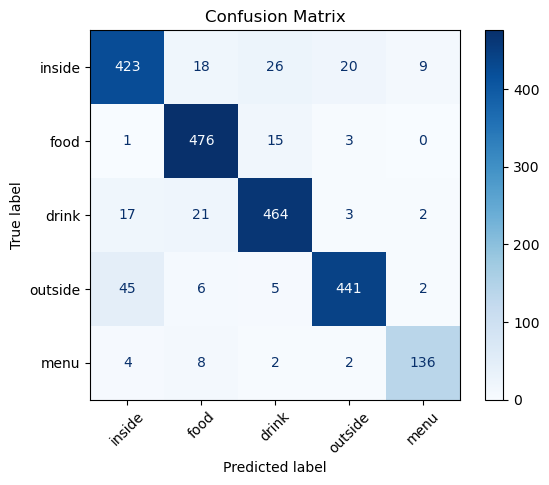

Classification Report:

              precision    recall  f1-score   support

      inside       0.86      0.85      0.86       496
        food       0.90      0.96      0.93       495
       drink       0.91      0.92      0.91       507
     outside       0.94      0.88      0.91       499
        menu       0.91      0.89      0.90       152

    accuracy                           0.90      2149
   macro avg       0.90      0.90      0.90      2149
weighted avg       0.90      0.90      0.90      2149

Accuracy: 0.9027


In [38]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Put model in eval mode
efficientnet.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:  # or val_loader
        images, labels = images.to(device), labels.to(device)
        outputs = efficientnet(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# === Confusion Matrix ===
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(class_to_idx.keys()))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# === Classification Report ===
report = classification_report(all_labels, all_preds, target_names=list(class_to_idx.keys()))
print("Classification Report:\n")
print(report)

# === Overall Accuracy ===
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Accuracy: {accuracy:.4f}")


## Tuning 1

***Unfreeze Specific Layers for Fine-Tuning:***
unfreeze just the last couple of layers to allow fine-tuning without destroying pretrained knowledge. 
- This gives the model some learning flexibility while keeping the early layers frozen

In [ ]:
print(efficientnet)

In [40]:
# Unfreeze last few layers in the feature extractor
for param in efficientnet.features[-3:].parameters():
    param.requires_grad = True


In [41]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, efficientnet.parameters()),
    lr=1e-4  # smaller LR for fine-tuning
)


In [42]:
best_val_acc = 0.0
patience = 3
counter = 0
best_model_state = None


In [43]:
print(device)

cuda


In [44]:
best_val_acc = 0.0
patience = 5
counter = 0
best_model_state = None

for epoch in range(num_epochs):
    
    # training logic ...
    efficientnet.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Metrics
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)

        loop.set_postfix(loss=loss.item())

    avg_loss = train_loss / total_train
    train_acc = train_correct / total_train
    print(f"Train Loss: {avg_loss:.4f} | Train Accuracy: {train_acc:.4f}")

    # Validation 
    efficientnet.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = efficientnet(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Validation Accuracy: {val_acc:.4f}")

    # EARLY STOPPING LOGIC: correctly indented inside the loop
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = efficientnet.state_dict()
        counter = 0
        print("Validation accuracy improved. Saving model...")
    else:
        counter += 1
        print(f"No improvement. Patience counter: {counter}/{patience}")
        if counter >= patience:
            print("Early stopping triggered.")
            break  

Epoch 1/10: 100%|████████████████████████████████████████████████████████| 538/538 [01:18<00:00,  6.86it/s, loss=0.664]


Train Loss: 0.2524 | Train Accuracy: 0.9115
Validation Accuracy: 0.9254
Validation accuracy improved. Saving model...


Epoch 2/10: 100%|███████████████████████████████████████████████████████| 538/538 [01:13<00:00,  7.32it/s, loss=0.0318]


Train Loss: 0.1470 | Train Accuracy: 0.9477
Validation Accuracy: 0.9273
Validation accuracy improved. Saving model...


Epoch 3/10: 100%|███████████████████████████████████████████████████████| 538/538 [01:13<00:00,  7.32it/s, loss=0.0818]


...

Train Loss: 0.0259 | Train Accuracy: 0.9915
Validation Accuracy: 0.9362
No improvement. Patience counter: 2/5


Epoch 9/10: 100%|████████████████████████████████████████████████████████| 538/538 [01:14<00:00,  7.25it/s, loss=0.343]


Train Loss: 0.0307 | Train Accuracy: 0.9896
Validation Accuracy: 0.9334
No improvement. Patience counter: 3/5


Epoch 10/10: 100%|█████████████████████████████████████████████████████| 538/538 [01:14<00:00,  7.24it/s, loss=0.00325]


Train Loss: 0.0294 | Train Accuracy: 0.9905
Validation Accuracy: 0.9306
No improvement. Patience counter: 4/5


In [45]:
if best_model_state:
    efficientnet.load_state_dict(best_model_state)


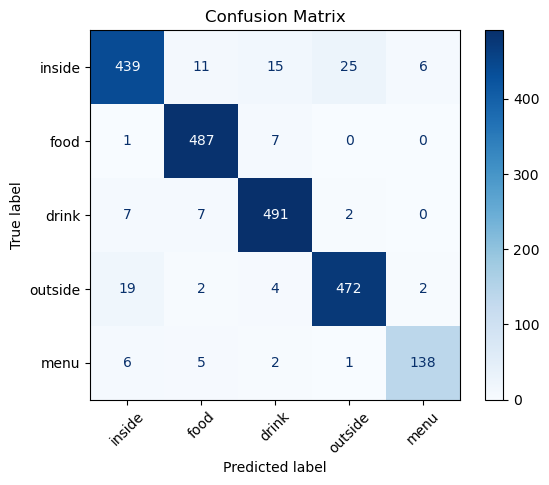

Classification Report:

              precision    recall  f1-score   support

      inside       0.93      0.89      0.91       496
        food       0.95      0.98      0.97       495
       drink       0.95      0.97      0.96       507
     outside       0.94      0.95      0.94       499
        menu       0.95      0.91      0.93       152

    accuracy                           0.94      2149
   macro avg       0.94      0.94      0.94      2149
weighted avg       0.94      0.94      0.94      2149

Accuracy: 0.9432


In [46]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Put model in eval mode
efficientnet.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:  # or val_loader
        images, labels = images.to(device), labels.to(device)
        outputs = efficientnet(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# === Confusion Matrix ===
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(class_to_idx.keys()))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# === Classification Report ===
report = classification_report(all_labels, all_preds, target_names=list(class_to_idx.keys()))
print("Classification Report:\n")
print(report)

# === Overall Accuracy ===
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Accuracy: {accuracy:.4f}")


## Tuning 2

Unfreeze the last 5 layers and replace the classifier with a deeper custom head to increase model flexibility and capture more complex patterns specific to the target dataset.

In [47]:
efficientnet.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(1280, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)


In [48]:
# Unfreeze deeper layers
for param in efficientnet.features[-5:].parameters():
    param.requires_grad = True

# New optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, efficientnet.parameters()),
    lr=1e-5
)


In [49]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, efficientnet.parameters()),
    lr=1e-5  # Lower LR for safe fine-tuning
)


In [50]:
best_val_acc = 0.0
patience = 5
counter = 0
best_model_state = None

In [51]:
efficientnet = efficientnet.to(device)

In [52]:
from tqdm import tqdm

num_epochs = 10

for epoch in range(num_epochs):
    efficientnet.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    loop = tqdm(train_loader, desc=f"Tuning2 | Epoch {epoch+1}/{num_epochs}")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)
        loop.set_postfix(loss=loss.item())

    avg_loss = train_loss / total_train
    train_acc = train_correct / total_train
    print(f"Train Loss: {avg_loss:.4f} | Train Accuracy: {train_acc:.4f}")

    # === Validation ===
    efficientnet.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = efficientnet(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Validation Accuracy: {val_acc:.4f}")

    # === Early stopping logic ===
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = efficientnet.state_dict()
        counter = 0
        print("Validation accuracy improved. Saving model...")
    else:
        counter += 1
        print(f"No improvement. Patience counter: {counter}/{patience}")
        if counter >= patience:
            print("Early stopping triggered.")
            break


Tuning2 | Epoch 1/10: 100%|██████████████████████████████████████████████| 538/538 [01:33<00:00,  5.78it/s, loss=0.361]


Train Loss: 0.7672 | Train Accuracy: 0.8781
Validation Accuracy: 0.9287
Validation accuracy improved. Saving model...


Tuning2 | Epoch 2/10: 100%|██████████████████████████████████████████████| 538/538 [01:32<00:00,  5.79it/s, loss=0.168]


Train Loss: 0.1623 | Train Accuracy: 0.9728
Validation Accuracy: 0.9408
Validation accuracy improved. Saving model...


Tuning2 | Epoch 3/10: 100%|█████████████████████████████████████████████| 538/538 [01:32<00:00,  5.79it/s, loss=0.0836]


...

Train Loss: 0.0259 | Train Accuracy: 0.9925
Validation Accuracy: 0.9473
No improvement. Patience counter: 2/5


Tuning2 | Epoch 9/10: 100%|████████████████████████████████████████████| 538/538 [01:33<00:00,  5.78it/s, loss=0.00136]


Train Loss: 0.0258 | Train Accuracy: 0.9924
Validation Accuracy: 0.9390
No improvement. Patience counter: 3/5


Tuning2 | Epoch 10/10: 100%|█████████████████████████████████████████████| 538/538 [01:32<00:00,  5.79it/s, loss=0.406]


Train Loss: 0.0201 | Train Accuracy: 0.9943
Validation Accuracy: 0.9427
No improvement. Patience counter: 4/5


In [53]:
print(device)

cuda


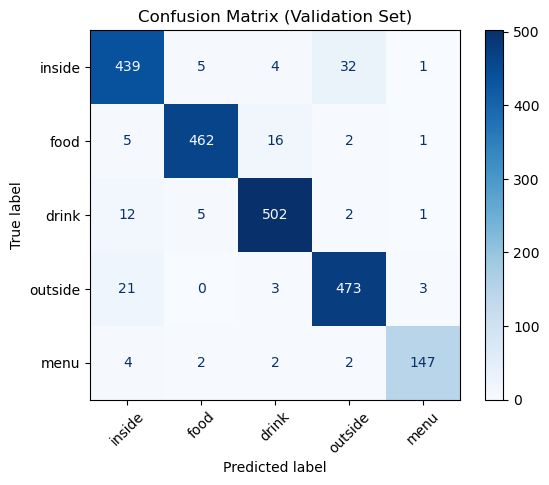

In [54]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Put model in eval mode
efficientnet.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader: 
        images, labels = images.to(device), labels.to(device)
        outputs = efficientnet(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# === Confusion Matrix ===
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(class_to_idx.keys()))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (Validation Set)")
plt.show()

In [55]:
# === Classification Report ===
report = classification_report(all_labels, all_preds, target_names=list(class_to_idx.keys()))
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

      inside       0.91      0.91      0.91       481
        food       0.97      0.95      0.96       486
       drink       0.95      0.96      0.96       522
     outside       0.93      0.95      0.94       500
        menu       0.96      0.94      0.95       157

    accuracy                           0.94      2146
   macro avg       0.95      0.94      0.94      2146
weighted avg       0.94      0.94      0.94      2146



In [56]:
# === Overall Accuracy ===
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.9427


In [57]:
if best_model_state:
    efficientnet.load_state_dict(best_model_state)

torch.save(efficientnet.state_dict(), "efficientnet_tuning2.pth")


## Testing the best model on Test data

In [58]:
if best_model_state:
    efficientnet.load_state_dict(best_model_state)


In [59]:
# Put model in evaluation mode
efficientnet.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:  
        images, labels = images.to(device), labels.to(device)
        outputs = efficientnet(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

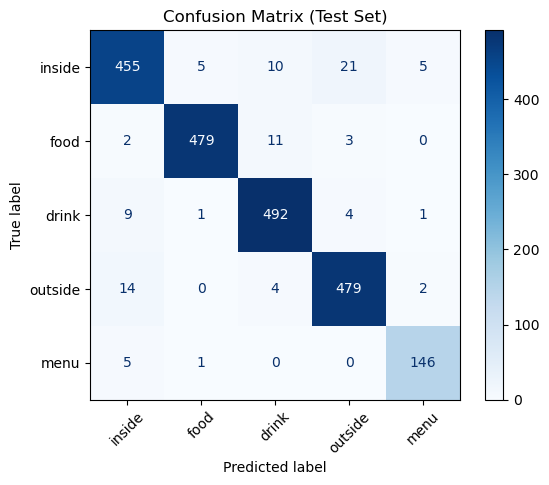

In [60]:
# === Confusion Matrix ===
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(class_to_idx.keys()))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (Test Set)")
plt.show()

In [61]:
# === Classification Report ===
report = classification_report(all_labels, all_preds, target_names=list(class_to_idx.keys()))
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

      inside       0.94      0.92      0.93       496
        food       0.99      0.97      0.98       495
       drink       0.95      0.97      0.96       507
     outside       0.94      0.96      0.95       499
        menu       0.95      0.96      0.95       152

    accuracy                           0.95      2149
   macro avg       0.95      0.96      0.95      2149
weighted avg       0.95      0.95      0.95      2149



In [62]:
# === Overall Accuracy ===
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9544


# Interpretation

In [ ]:
pip install lime

In [64]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [65]:
# Prepare a test image
images, labels = next(iter(test_loader)) 
image_tensor = images[0].to(device)
true_label = labels[0].item()

# Convert to numpy for LIME
image_np = (image_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

In [66]:
def predict_fn(images_np):
    images = np.transpose(images_np, (0, 3, 1, 2))  # NHWC -> NCHW
    images = torch.tensor(images).float() / 255.0
    images = images.to(device)
    
    # Normalize as EfficientNet expects
    normalize = torch.nn.Sequential(
        torch.nn.BatchNorm2d(3)
    )
    # Optional: use torchvision.transforms.Normalize manually if required

    with torch.no_grad():
        outputs = efficientnet(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
    return probs.cpu().numpy()

In [67]:
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    image_np,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)


  0%|          | 0/1000 [00:00<?, ?it/s]

In [68]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=20,
    hide_rest=False
)

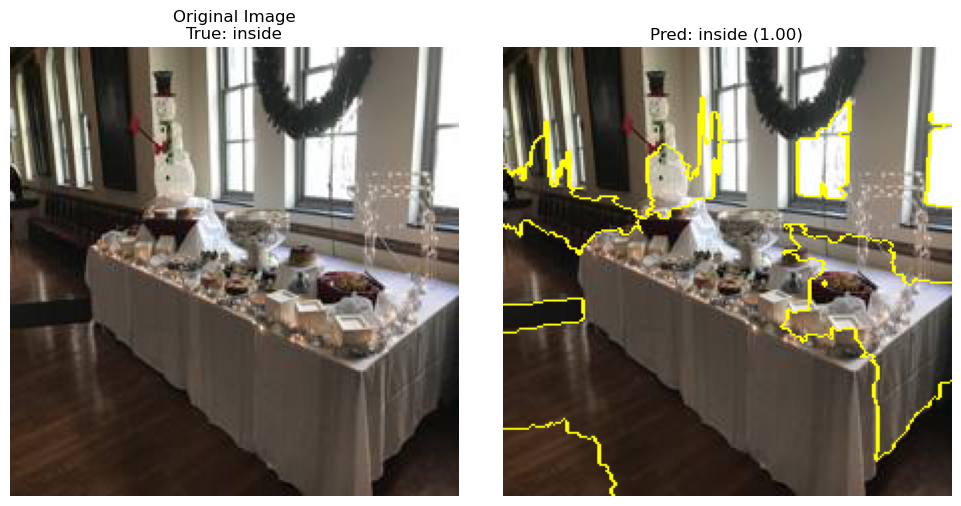

In [69]:
idx_to_class = {v: k for k, v in class_to_idx.items()}
pred_label = explanation.top_labels[0]
pred_confidence = predict_fn(np.expand_dims(image_np, axis=0))[0][pred_label]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Original image
ax[0].imshow(image_np)
ax[0].set_title(f"Original Image\nTrue: {idx_to_class[true_label]}")
ax[0].axis('off')

# LIME explained image
ax[1].imshow(mark_boundaries(temp / 255.0, mask))
ax[1].set_title(f"Pred: {idx_to_class[pred_label]} ({pred_confidence:.2f})")
ax[1].axis('off')

plt.tight_layout()
plt.show()

***Left: The original test image and the true label***

***Right: The LIME-highlighted regions contributing to the prediction***, with:
- Predicted label
- Confidence score

  0%|          | 0/1000 [00:00<?, ?it/s]

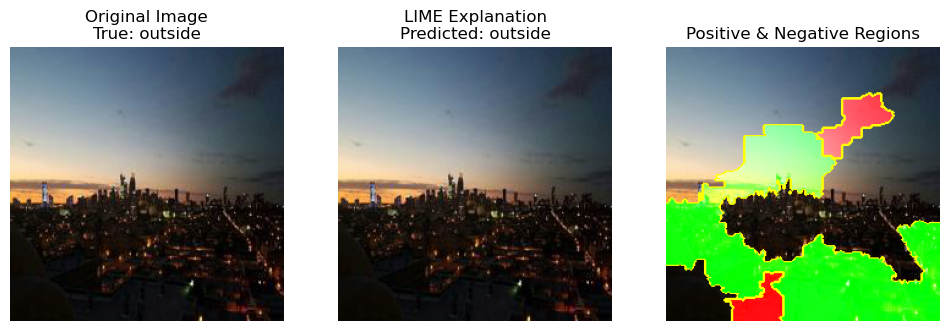

  0%|          | 0/1000 [00:00<?, ?it/s]

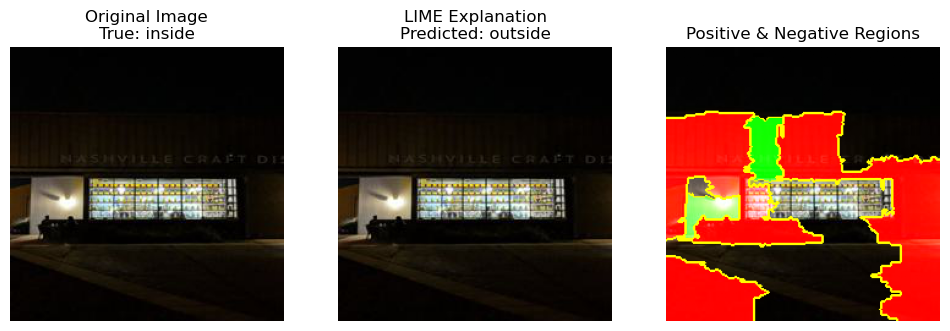

  0%|          | 0/1000 [00:00<?, ?it/s]

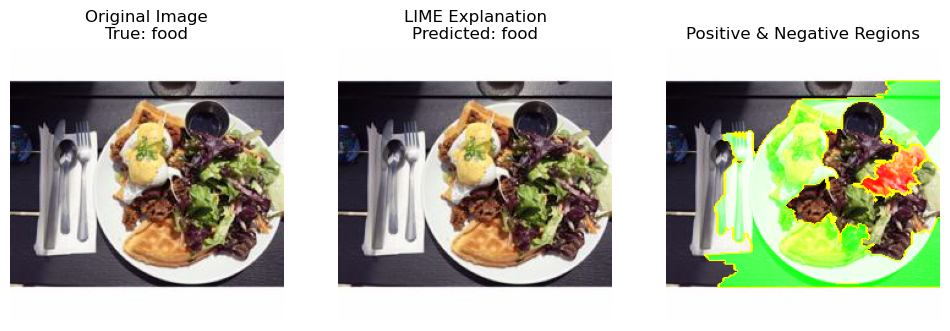

  0%|          | 0/1000 [00:00<?, ?it/s]

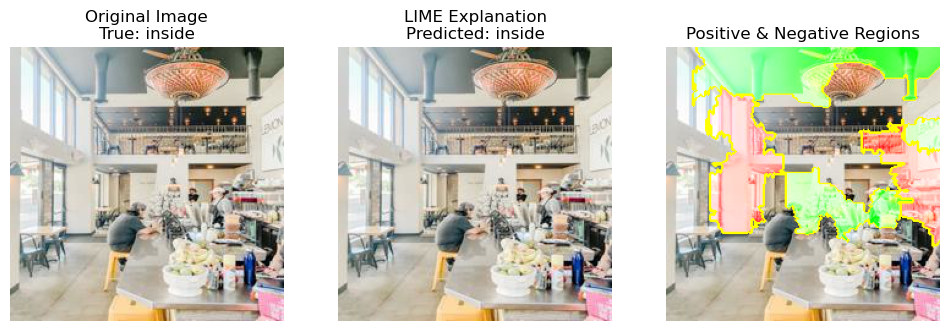

  0%|          | 0/1000 [00:00<?, ?it/s]

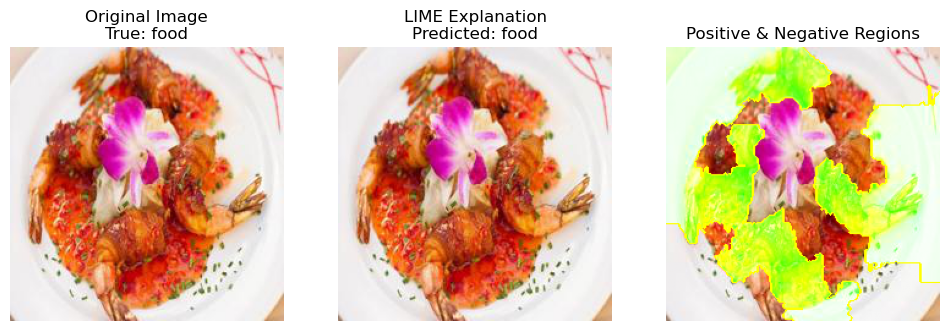

In [70]:
# Number of images to visualize
num_images = 5

# Reverse class map
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()

# Get all test dataset indices
test_indices = list(range(len(test_loader.dataset)))

# Randomly select images indices
selected_indices = random.sample(test_indices, num_images)

for idx in selected_indices:
    # Get image and true label
    image, true_label = test_loader.dataset[idx]
    
    # Convert image tensor to numpy for LIME (HWC format and scaled 0-255)
    image_np = image.permute(1, 2, 0).numpy()
    image_np = (image_np * 255).astype(np.uint8)
    
    # Run model prediction
    efficientnet.eval()
    with torch.no_grad():
        input_tensor = image.unsqueeze(0).to(device)
        output = efficientnet(input_tensor)
        pred_label = output.argmax(dim=1).item()
    
    # Explain with LIME
    explanation = explainer.explain_instance(
        image_np,
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )
    
    # Get image and mask for predicted label
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=False,
        num_features=10,
        hide_rest=False
    )
    
    # Plot
    plt.figure(figsize=(12, 5))
    
    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title(f"Original Image\nTrue: {idx_to_class[int(true_label)]}")
    plt.axis('off')
    
    # Predicted label image
    plt.subplot(1, 3, 2)
    plt.imshow(image_np)
    plt.title(f"LIME Explanation\nPredicted: {idx_to_class[int(pred_label)]}")
    plt.axis('off')
    
    # LIME explanation overlay
    plt.subplot(1, 3, 3)
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title("Positive & Negative Regions")
    plt.axis('off')
    plt.show()



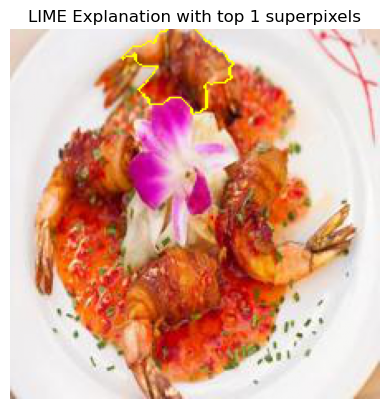

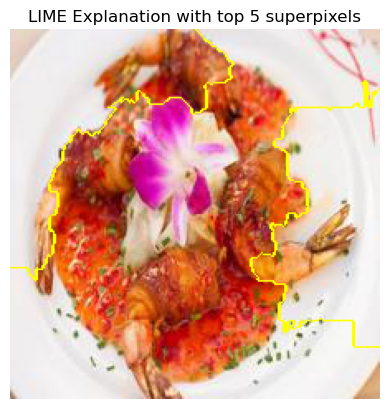

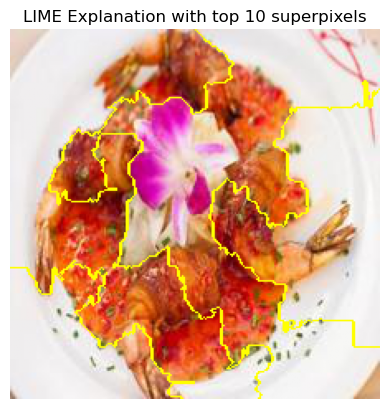

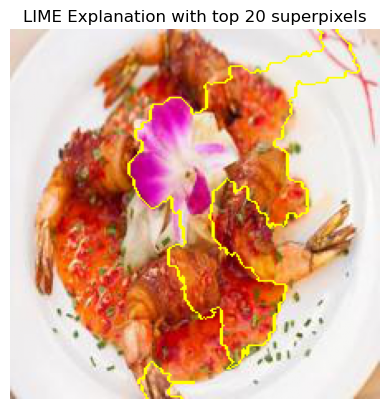

In [71]:
for k in [1, 5, 10, 20]:
    temp, mask = explanation.get_image_and_mask(pred_label, num_features=k)
    plt.figure()
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title(f"LIME Explanation with top {k} superpixels")
    plt.axis('off')


# Summary

### Base Model (1st run)
- Train Accuracy: 88.4%
- Validation Accuracy: 90.3%
- Observation: Good initial performance, slight underfitting. Solid baseline across all classes.

### Tuning 1 (Custom classifier head)
- Train Accuracy: 99.1%
- Validation Accuracy: 93.1%
- Observation: Significant gain in performance due to deeper classifier. Balanced precision and recall across all categories. Small overfitting visible, but manageable.

### Tuning 2 (Classifier + unfreezing last 5 layers)
- Train Accuracy: 99.4%
- Validation Accuracy: 94.3%
- Test Accuracy: 95.4%
  
***Observation***:
- Best overall performance.
- Strong generalization — improvement sustained on the unseen test set.
- Food, drink, and menu classes have near-perfect metrics.
- Inside class is relatively weaker (F1 ≈ 0.93), possibly due to more visual variability.